Modules Utilized

NumPy

Pandas

Matplotlib

Seaborn

Scikit-Learn

Imbalanced-learn (if required)

Joblib/Pickle


Step 1: Problem Statement and Dataset Collection

Sources for Dataset Collection

Kaggle


The objective of this project is to develop a machine learning model that predicts whether an individual is an early waker based on demographic information, sleep patterns, lifestyle habits, physical activity, dietary habits, and health-related factors. Early wake-up behavior is associated with various aspects of health and productivity, but identifying the factors that influence it can be challenging. By analyzing these factors, the model aims to classify individuals as Early Waker (Yes) or Not an Early Waker (No). The insights obtained from this model can help healthcare professionals, wellness organizations, and fitness applications provide personalized lifestyle recommendations and promote healthier daily routines.

**Requirements**

Minimum 1000 rows (recommended)

Structured/tabular data

Classification

Target variable:Early_Waker



**Target Variable**

Early_Waker

Type: Classification
Classes:
Yes – The individual is an early waker.
No – The individual is not an early waker.
Features Available

The dataset contains 63 input features describing an individual's demographic details, sleep habits, lifestyle, physical activity, dietary habits, and health indicators. Some important features include:

Person_ID

Age

Gender

Height_cm

Weight_kg

BMI

Country

Occupation

Marital_Status

Sleep_Time

Wake_Up_Time

Sleep_Duration_Hours

Sleep_Quality_Score

Number_of_Night_Awakenings

Exercise_Frequency_Per_Week

Daily_Steps

Morning_Workout

Water_Intake_Liters

Daily_Calorie_Intake

Fruit_Intake_Per_Day

Vegetable_Intake_Per_Day

Smoking_Status

Alcohol_Consumption

Stress_Level

Resting_Heart_Rate

Blood_Sugar_Level

Health_Score

Fitness_Level

Wellness_Category
...and other health- and lifestyle-related features.

**Business Objective**

The objective of this project is to build a machine learning model that predicts whether an individual is an early waker based on their health, lifestyle, sleep patterns, and demographic information. The model can help healthcare professionals, wellness organizations, and fitness applications understand the factors associated with early waking habits and provide personalized recommendations to improve overall health, sleep quality, and daily productivity.


✅ STEP 1: IMPORT LIBRARIES

In [ ]:
# Data Manipulation
import pandas as pd
import numpy as np

# Data Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Ignore warnings
import warnings
warnings.filterwarnings("ignore")

Step 2: Load the Dataset

In [ ]:
# Load dataset
df = pd.read_csv("/content/early_wakeup_health_dataset.csv")

Display Shape

In [ ]:

df.shape

(10000, 64)

Display First Five Records

In [ ]:
df.head()

,Person_ID,Age,Gender,Height_cm,Weight_kg,BMI,Country,Occupation,Marital_Status,Wake_Up_Time,...,Obesity_Risk,Hypertension_Risk,Diabetes_Risk,Cardiovascular_Risk,Sleep_Disorder_Risk,Health_Score,Fitness_Level,Healthy_Aging_Score,Wellness_Category,Early_Waker
0,P00001,76,Female,158.8,62.1,24.63,Italy,Entrepreneur,Widowed,08:59,...,Low,High,Medium,Medium,Low,87.3,Excellent,81.8,Excellent,No
1,P00002,49,Female,160.9,68.5,26.45,USA,Freelancer,Single,06:35,...,Medium,Medium,Medium,Low,Medium,72.0,Good,75.2,Good,No
2,P00003,51,Female,151.9,54.8,23.77,Mexico,Nurse,Single,07:31,...,Low,Medium,Medium,Low,Low,75.2,Good,77.1,Good,No
3,P00004,48,Male,167.6,81.3,28.93,Australia,Laborer,Single,08:36,...,Medium,Medium,Low,Low,Medium,82.7,Excellent,87.1,Excellent,No
4,P00005,68,Female,171.9,75.4,25.51,USA,Software Engineer,Married,07:07,...,Medium,High,Medium,Medium,Low,62.7,Average,58.1,Average,No


Display Last Five Records

In [ ]:







df.tail()

,Person_ID,Age,Gender,Height_cm,Weight_kg,BMI,Country,Occupation,Marital_Status,Wake_Up_Time,...,Obesity_Risk,Hypertension_Risk,Diabetes_Risk,Cardiovascular_Risk,Sleep_Disorder_Risk,Health_Score,Fitness_Level,Healthy_Aging_Score,Wellness_Category,Early_Waker
9995,P09996,66,Male,170.2,86.4,29.84,Nigeria,Teacher,Single,07:11,...,Medium,High,High,Medium,Low,67.8,Good,53.8,Good,No
9996,P09997,70,Male,182.3,86.9,26.14,Canada,Athlete,Single,09:33,...,Medium,High,Medium,Medium,Low,84.8,Excellent,78.5,Excellent,No
9997,P09998,29,Male,170.4,81.2,27.96,Italy,Lawyer,Married,07:58,...,Medium,Low,Medium,Low,Medium,54.2,Average,59.2,Average,No
9998,P09999,22,Male,186.5,78.3,22.52,India,Chef,Single,06:39,...,Low,Medium,Medium,Low,Medium,78.9,Good,84.2,Good,No
9999,P10000,58,Male,177.8,63.9,20.22,Brazil,Freelancer,Single,05:06,...,Low,Low,Low,Low,Low,88.7,Excellent,90.4,Excellent,Yes


Check Data Types

In [ ]:
df.dtypes

,0
Person_ID,object
Age,int64
Gender,object
Height_cm,float64
Weight_kg,float64
...,...
Health_Score,float64
Fitness_Level,object
Healthy_Aging_Score,float64
Wellness_Category,object


Step 3: Dataset Exploration

Dataset Information

In [ ]:

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 64 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   Person_ID                       10000 non-null  object 
 1   Age                             10000 non-null  int64  
 2   Gender                          10000 non-null  object 
 3   Height_cm                       10000 non-null  float64
 4   Weight_kg                       10000 non-null  float64
 5   BMI                             10000 non-null  float64
 6   Country                         10000 non-null  object 
 7   Occupation                      10000 non-null  object 
 8   Marital_Status                  10000 non-null  object 
 9   Wake_Up_Time                    10000 non-null  object 
 10  Sleep_Time                      10000 non-null  object 
 11  Sleep_Duration_Hours            10000 non-null  float64
 12  Sleep_Quality_Score             1

Shape of Dataset


In [ ]:
print("Rows :", df.shape[0])
print("Columns :", df.shape[1])

Rows : 10000
Columns : 64


Column Names

In [ ]:
df.columns

Index(['Person_ID', 'Age', 'Gender', 'Height_cm', 'Weight_kg', 'BMI',
       'Country', 'Occupation', 'Marital_Status', 'Wake_Up_Time', 'Sleep_Time',
       'Sleep_Duration_Hours', 'Sleep_Quality_Score',
       'Number_of_Night_Awakenings', 'Weekend_Sleep_Difference_Hours',
       'Nap_Frequency_Per_Week', 'Screen_Time_Before_Bed_Hours',
       'Exercise_Frequency_Per_Week', 'Exercise_Duration_Minutes',
       'Exercise_Type', 'Daily_Steps', 'Morning_Workout', 'Workout_Intensity',
       'Gym_Member', 'Daily_Calorie_Intake', 'Water_Intake_Liters',
       'Fruit_Intake_Per_Day', 'Vegetable_Intake_Per_Day',
       'Protein_Intake_Grams', 'Sugary_Drinks_Per_Week',
       'Fast_Food_Meals_Per_Week', 'Breakfast_Regularity_Score',
       'Smoking_Status', 'Alcohol_Consumption', 'Stress_Level',
       'Working_Hours_Per_Day', 'Sitting_Hours_Per_Day', 'Outdoor_Time_Hours',
       'Social_Interaction_Score', 'Meditation_Practice', 'Resting_Heart_Rate',
       'Systolic_BP', 'Diastolic_BP', 'Cho

Missing Values

In [ ]:
df.isnull().sum()

,0
Person_ID,0
Age,0
Gender,0
Height_cm,0
Weight_kg,0
...,...
Health_Score,0
Fitness_Level,0
Healthy_Aging_Score,0
Wellness_Category,0


Duplicate Records

In [ ]:

df.duplicated().sum()

np.int64(0)

Statistical Summary

In [ ]:
df.describe()

,Age,Height_cm,Weight_kg,BMI,Sleep_Duration_Hours,Sleep_Quality_Score,Number_of_Night_Awakenings,Weekend_Sleep_Difference_Hours,Nap_Frequency_Per_Week,Screen_Time_Before_Bed_Hours,...,Fatigue_Level_Score,Immune_Health_Score,Mood_Score,Anxiety_Score,Depression_Risk_Score,Productivity_Score,Focus_Concentration_Score,Life_Satisfaction_Score,Health_Score,Healthy_Aging_Score
count,10000.0000,10000.000000,10000.00000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,...,10000.000000,10000.00000,10000.000000,10000.000000,10000.000000,10000.00000,10000.00000,10000.000000,10000.000000,10000.000000
mean,44.6667,168.649160,73.10734,25.626963,7.229332,6.020190,0.839100,1.027020,2.120800,1.144012,...,3.124640,6.56333,6.779650,5.133470,2.184520,7.06533,6.85799,7.416720,74.201360,74.812320
std,17.5172,9.876706,16.29195,4.870317,1.118486,1.585689,0.936215,0.787941,1.905196,1.044281,...,1.705843,1.06034,1.255232,1.496242,1.286404,1.14750,0.95254,1.147736,12.266227,14.627688
min,18.0000,145.000000,33.60000,16.000000,4.000000,1.000000,0.000000,-1.000000,0.000000,0.000000,...,1.000000,2.60000,2.000000,1.000000,1.000000,2.80000,3.50000,2.900000,27.300000,12.400000
25%,29.7500,161.400000,61.30000,22.170000,6.470000,4.900000,0.000000,0.497500,0.750000,0.330000,...,1.700000,5.90000,5.900000,4.100000,1.000000,6.30000,6.20000,6.600000,66.000000,65.300000
50%,43.0000,168.200000,72.00000,25.580000,7.230000,6.000000,1.000000,1.030000,2.000000,0.810000,...,2.900000,6.60000,6.800000,5.100000,1.800000,7.00000,6.90000,7.400000,74.600000,75.700000
75%,58.0000,175.500000,83.50000,28.862500,7.980000,7.100000,1.000000,1.560000,3.000000,1.650000,...,4.300000,7.30000,7.700000,6.200000,2.900000,7.90000,7.50000,8.200000,82.800000,85.700000
max,80.0000,205.500000,166.60000,44.560000,10.000000,9.800000,6.000000,3.810000,7.000000,4.000000,...,10.000000,10.00000,10.000000,10.000000,8.800000,10.00000,10.00000,10.000000,100.000000,100.000000


Target Variable Analysis

In [ ]:
df["Early_Waker"].value_counts()

,count
Early_Waker,
No,5842
Yes,4158


Percentage distribution

In [ ]:
df["Early_Waker"].value_counts(normalize=True)*100

,proportion
Early_Waker,
No,58.42
Yes,41.58


Visualization

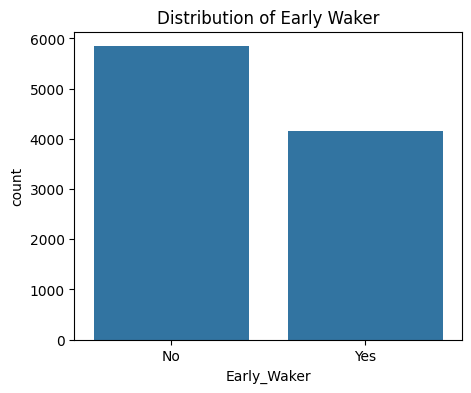

In [ ]:
plt.figure(figsize=(5,4))
sns.countplot(x="Early_Waker", data=df)
plt.title("Distribution of Early Waker")
plt.show()

Feature Understanding

Numerical Features

In [ ]:
numerical_columns = df.select_dtypes(include=np.number).columns

numerical_columns

Index(['Age', 'Height_cm', 'Weight_kg', 'BMI', 'Sleep_Duration_Hours',
       'Sleep_Quality_Score', 'Number_of_Night_Awakenings',
       'Weekend_Sleep_Difference_Hours', 'Nap_Frequency_Per_Week',
       'Screen_Time_Before_Bed_Hours', 'Exercise_Frequency_Per_Week',
       'Exercise_Duration_Minutes', 'Daily_Steps', 'Daily_Calorie_Intake',
       'Water_Intake_Liters', 'Fruit_Intake_Per_Day',
       'Vegetable_Intake_Per_Day', 'Protein_Intake_Grams',
       'Sugary_Drinks_Per_Week', 'Fast_Food_Meals_Per_Week',
       'Breakfast_Regularity_Score', 'Stress_Level', 'Working_Hours_Per_Day',
       'Sitting_Hours_Per_Day', 'Outdoor_Time_Hours',
       'Social_Interaction_Score', 'Resting_Heart_Rate', 'Systolic_BP',
       'Diastolic_BP', 'Cholesterol_Level', 'Blood_Sugar_Level',
       'Energy_Level_Score', 'Fatigue_Level_Score', 'Immune_Health_Score',
       'Mood_Score', 'Anxiety_Score', 'Depression_Risk_Score',
       'Productivity_Score', 'Focus_Concentration_Score',
       'Life_Satis

Categorical Features

In [ ]:
categorical_columns = df.select_dtypes(include="object").columns

categorical_columns

Index(['Person_ID', 'Gender', 'Country', 'Occupation', 'Marital_Status',
       'Wake_Up_Time', 'Sleep_Time', 'Exercise_Type', 'Morning_Workout',
       'Workout_Intensity', 'Gym_Member', 'Smoking_Status',
       'Alcohol_Consumption', 'Meditation_Practice', 'Obesity_Risk',
       'Hypertension_Risk', 'Diabetes_Risk', 'Cardiovascular_Risk',
       'Sleep_Disorder_Risk', 'Fitness_Level', 'Wellness_Category',
       'Early_Waker'],
      dtype='object')

Continuous Variables

In [ ]:


continuous_columns = [
    'Height_cm',
    'Weight_kg',
    'BMI',
    'Health_Score',
    'Healthy_Aging_Score'
]

continuous_columns

['Height_cm', 'Weight_kg', 'BMI', 'Health_Score', 'Healthy_Aging_Score']

Discrete Variables

In [ ]:
discrete_columns = [
    'Age',
    'Daily_Steps',
    'Heart_Rate'
]

discrete_columns

['Age', 'Daily_Steps', 'Heart_Rate']

Step 4: Exploratory Data Analysis (EDA)

Non-Visual Analysis

Mean

In [ ]:
df[numerical_columns].mean()

,0
Age,44.666700
Height_cm,168.649160
Weight_kg,73.107340
BMI,25.626963
Sleep_Duration_Hours,7.229332
Sleep_Quality_Score,6.020190
Number_of_Night_Awakenings,0.839100
Weekend_Sleep_Difference_Hours,1.027020
Nap_Frequency_Per_Week,2.120800
Screen_Time_Before_Bed_Hours,1.144012


Median

In [ ]:
df[numerical_columns].median()

,0
Age,43.00
Height_cm,168.20
Weight_kg,72.00
BMI,25.58
Sleep_Duration_Hours,7.23
Sleep_Quality_Score,6.00
Number_of_Night_Awakenings,1.00
Weekend_Sleep_Difference_Hours,1.03
Nap_Frequency_Per_Week,2.00
Screen_Time_Before_Bed_Hours,0.81


Mode

In [ ]:
df.mode().iloc[0]

,0
Person_ID,P00001
Age,18.0
Gender,Male
Height_cm,169.2
Weight_kg,72.0
...,...
Health_Score,100.0
Fitness_Level,Good
Healthy_Aging_Score,100.0
Wellness_Category,Good


Standard Deviation

In [ ]:
df[numerical_columns].std()

,0
Age,17.517200
Height_cm,9.876706
Weight_kg,16.291950
BMI,4.870317
Sleep_Duration_Hours,1.118486
Sleep_Quality_Score,1.585689
Number_of_Night_Awakenings,0.936215
Weekend_Sleep_Difference_Hours,0.787941
Nap_Frequency_Per_Week,1.905196
Screen_Time_Before_Bed_Hours,1.044281


Percentiles

In [ ]:
df[numerical_columns].quantile([0.25,0.50,0.75])

,Age,Height_cm,Weight_kg,BMI,Sleep_Duration_Hours,Sleep_Quality_Score,Number_of_Night_Awakenings,Weekend_Sleep_Difference_Hours,Nap_Frequency_Per_Week,Screen_Time_Before_Bed_Hours,...,Fatigue_Level_Score,Immune_Health_Score,Mood_Score,Anxiety_Score,Depression_Risk_Score,Productivity_Score,Focus_Concentration_Score,Life_Satisfaction_Score,Health_Score,Healthy_Aging_Score
0.25,29.75,161.4,61.3,22.1700,6.47,4.9,0.0,0.4975,0.75,0.33,...,1.7,5.9,5.9,4.1,1.0,6.3,6.2,6.6,66.0,65.3
0.50,43.00,168.2,72.0,25.5800,7.23,6.0,1.0,1.0300,2.00,0.81,...,2.9,6.6,6.8,5.1,1.8,7.0,6.9,7.4,74.6,75.7
0.75,58.00,175.5,83.5,28.8625,7.98,7.1,1.0,1.5600,3.00,1.65,...,4.3,7.3,7.7,6.2,2.9,7.9,7.5,8.2,82.8,85.7


Correlation Matrix

In [ ]:
correlation = df[numerical_columns].corr()

correlation

,Age,Height_cm,Weight_kg,BMI,Sleep_Duration_Hours,Sleep_Quality_Score,Number_of_Night_Awakenings,Weekend_Sleep_Difference_Hours,Nap_Frequency_Per_Week,Screen_Time_Before_Bed_Hours,...,Fatigue_Level_Score,Immune_Health_Score,Mood_Score,Anxiety_Score,Depression_Risk_Score,Productivity_Score,Focus_Concentration_Score,Life_Satisfaction_Score,Health_Score,Healthy_Aging_Score
Age,1.000000,-0.004938,0.076464,0.092279,-0.011609,-0.004994,-0.004313,-0.000423,-0.016036,-0.009439,...,-0.006178,0.013460,0.004463,0.007613,0.008549,-0.007354,0.000488,0.002778,-0.130807,-0.364697
Height_cm,-0.004938,1.000000,0.510193,-0.019757,-0.015962,0.009491,-0.003771,0.004322,-0.005165,-0.002789,...,-0.009174,0.006359,0.026637,-0.015255,-0.017709,0.015291,0.011998,0.017892,0.020286,0.016801
Weight_kg,0.076464,0.510193,1.000000,0.843770,0.001751,0.000579,-0.019516,0.008530,-0.013116,0.003611,...,-0.002301,0.009252,0.015333,-0.003398,-0.012152,0.009085,0.001748,0.011674,-0.394317,-0.406633
BMI,0.092279,-0.019757,0.843770,1.000000,0.014035,-0.005281,-0.022324,0.009150,-0.010856,0.004888,...,0.003138,0.007444,0.001927,0.005182,-0.004813,0.000099,-0.006665,0.004240,-0.475202,-0.487395
Sleep_Duration_Hours,-0.011609,-0.015962,0.001751,0.014035,1.000000,0.202494,-0.033784,0.004006,-0.004006,-0.013475,...,-0.124323,0.014538,0.088660,-0.070244,-0.071599,0.103474,0.090122,0.044442,0.088305,0.077768
Sleep_Quality_Score,-0.004994,0.009491,0.000579,-0.005281,0.202494,1.000000,-0.170521,0.021284,0.006886,0.002957,...,-0.612535,0.013354,0.570491,-0.467457,-0.471621,0.509882,0.420781,0.348251,0.479700,0.399710
Number_of_Night_Awakenings,-0.004313,-0.003771,-0.019516,-0.022324,-0.033784,-0.170521,1.000000,-0.017776,-0.002559,0.006235,...,0.097186,-0.003335,-0.090876,0.058605,0.066291,-0.094311,-0.072109,-0.050669,-0.065783,-0.051635
Weekend_Sleep_Difference_Hours,-0.000423,0.004322,0.008530,0.009150,0.004006,0.021284,-0.017776,1.000000,-0.000751,0.001531,...,-0.012388,-0.003485,0.013515,0.001218,-0.005347,-0.001524,0.025093,0.002347,0.010555,0.009574
Nap_Frequency_Per_Week,-0.016036,-0.005165,-0.013116,-0.010856,-0.004006,0.006886,-0.002559,-0.000751,1.000000,0.003254,...,0.003048,0.000733,0.001522,-0.003078,-0.002126,0.015763,-0.001166,-0.003887,0.005296,0.009875
Screen_Time_Before_Bed_Hours,-0.009439,-0.002789,0.003611,0.004888,-0.013475,0.002957,0.006235,0.001531,0.003254,1.000000,...,0.159852,0.004042,0.009886,-0.000617,-0.000644,0.007375,-0.329291,0.005758,0.004941,0.007635


Observations

Example:

Age ranges from young adults to elderly.

BMI values vary across individuals.

Some variables have a positive

correlation with Health Score.

Some features show weak correlation and may not contribute much to prediction

Visual Analysis

Histogram

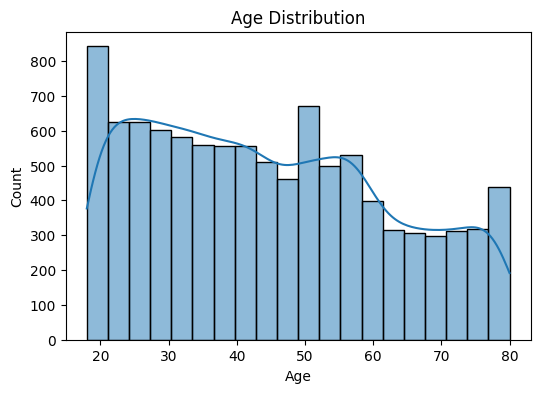

In [ ]:
plt.figure(figsize=(6,4))

sns.histplot(df["Age"], bins=20, kde=True)

plt.title("Age Distribution")

plt.show()

Boxplot

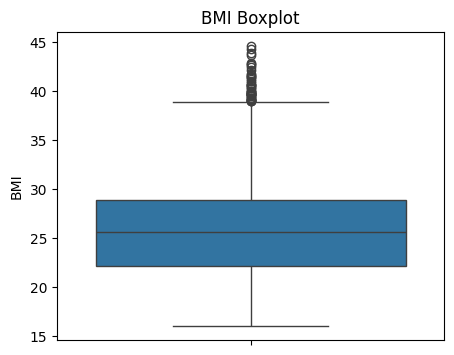

In [ ]:
plt.figure(figsize=(5,4))

sns.boxplot(y=df["BMI"])

plt.title("BMI Boxplot")

plt.show()

Countplot

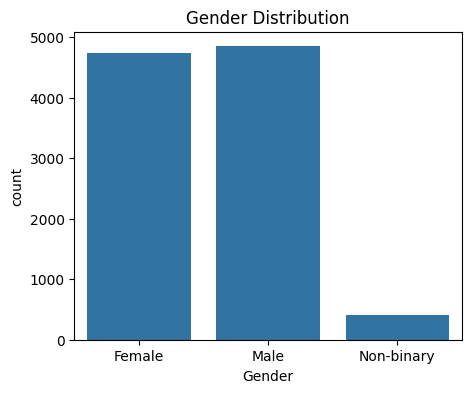

In [ ]:
plt.figure(figsize=(5,4))

sns.countplot(x="Gender", data=df)

plt.title("Gender Distribution")

plt.show()

Scatter Plot

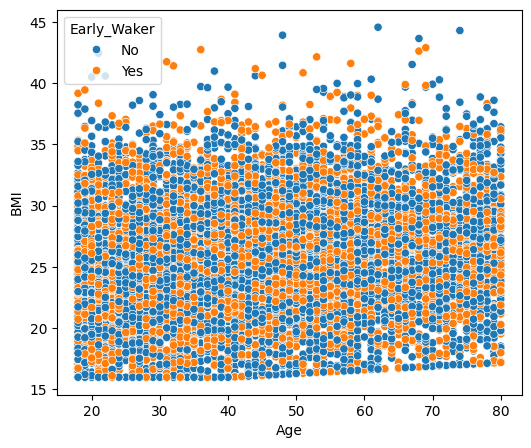

In [ ]:
plt.figure(figsize=(6,5))

sns.scatterplot(
    x="Age",
    y="BMI",
    hue="Early_Waker",
    data=df
)

plt.show()

Bar Plot

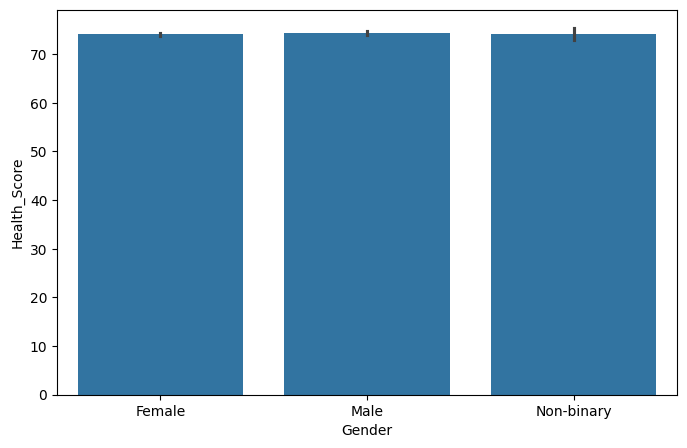

In [ ]:
plt.figure(figsize=(8,5))

sns.barplot(
    x="Gender",
    y="Health_Score",
    data=df
)

plt.show()

Line Plot

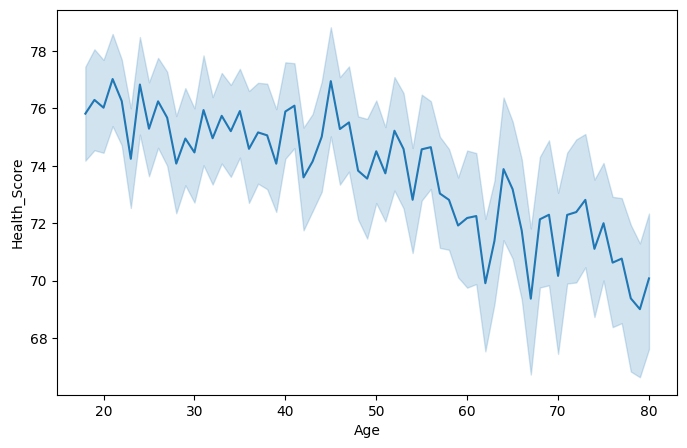

In [ ]:
plt.figure(figsize=(8,5))

sns.lineplot(
    x="Age",
    y="Health_Score",
    data=df
)

plt.show()

Heatmap

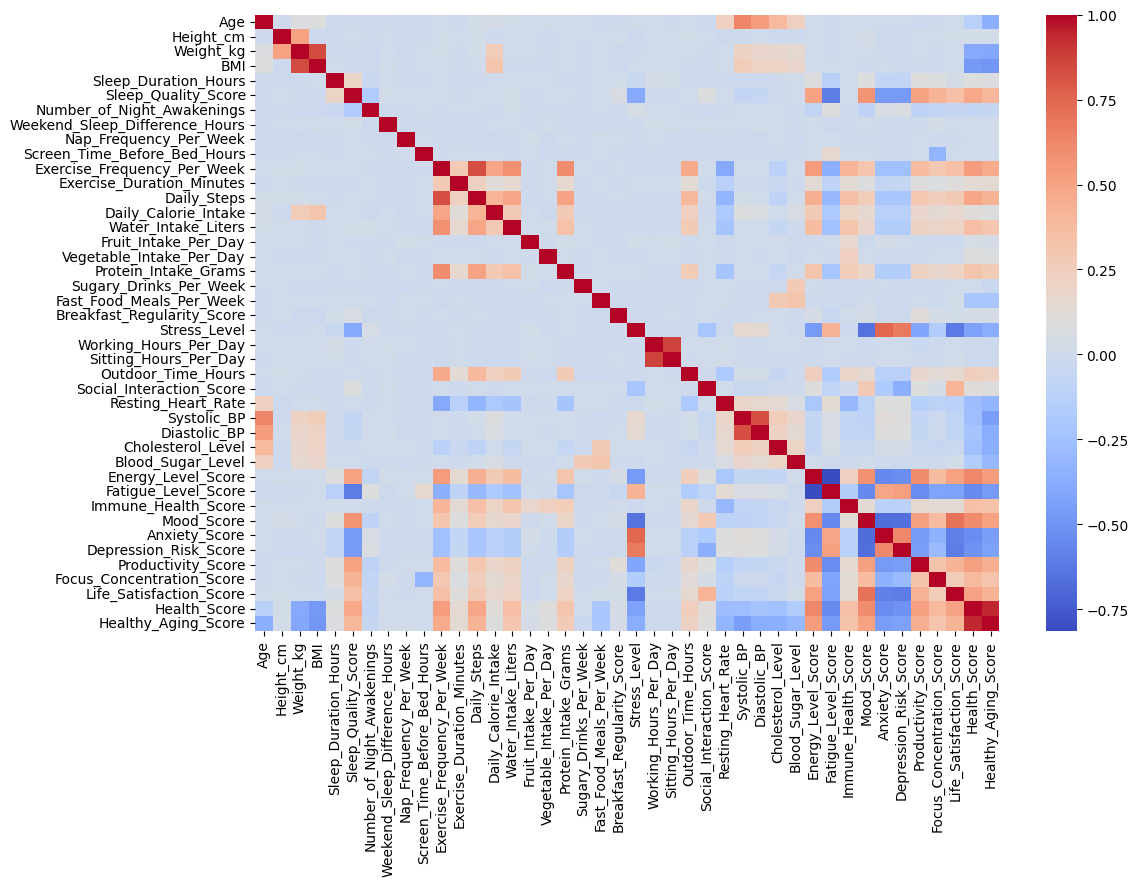

In [ ]:
plt.figure(figsize=(12,8))

sns.heatmap(
    correlation,
    cmap="coolwarm"
)

plt.show()

Pair Plot

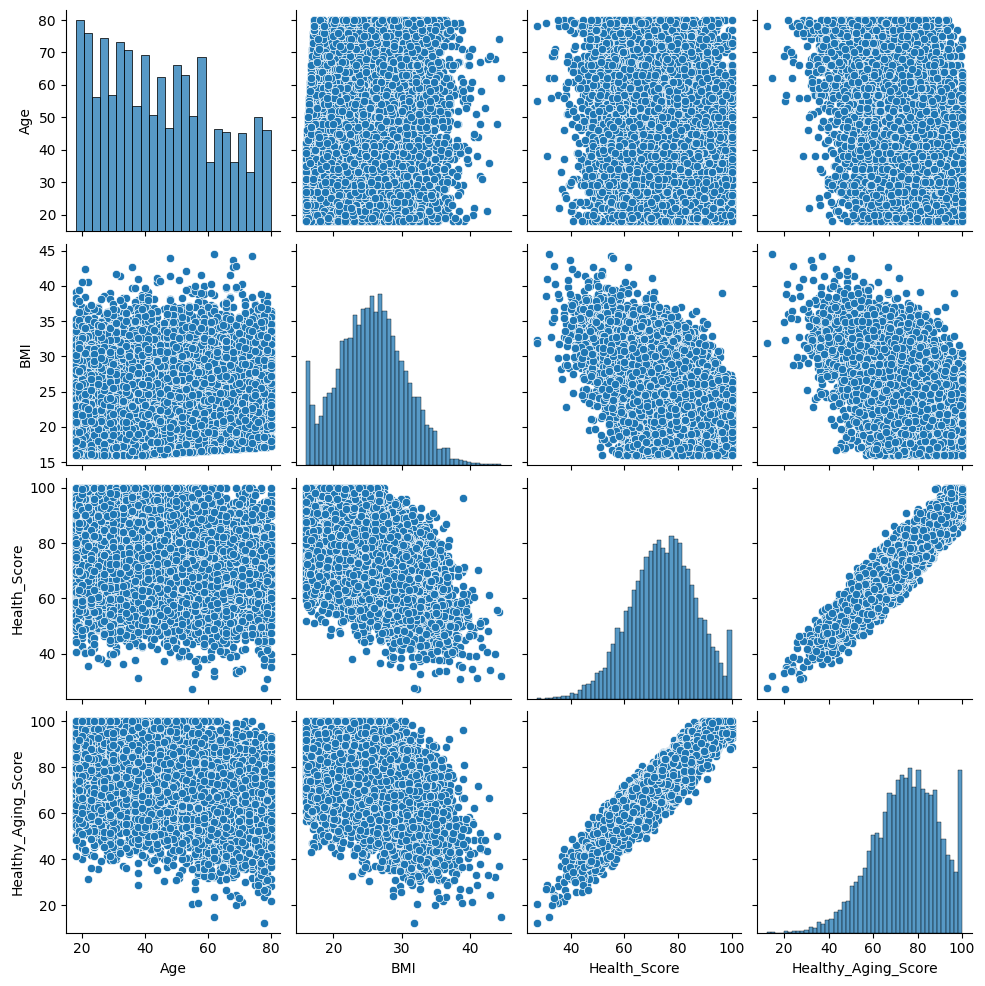

In [ ]:
pair_cols = [
    "Age",
    "BMI",
    "Health_Score",
    "Healthy_Aging_Score"
]

sns.pairplot(df[pair_cols])

plt.show()

Observations

Example:

Most individuals have a normal BMI.

Health Score tends to decrease for some age groups.
Some outliers exist in BMI.

The dataset appears balanced (or imbalanced—based on your Early_Waker distribution)

Step 5: Data Cleaning

Missing Value Analysis

In [ ]:
missing = df.isnull().sum()
missing[missing > 0]

,0
Exercise_Type,824
Workout_Intensity,824
Alcohol_Consumption,3014


Observation
Exercise_Type has 824 missing values.

Workout_Intensity has 824 missing values.

Alcohol_Consumption has 3014 missing values.

Handle Missing Values

Numerical Columns (Mean)

In [ ]:
num_cols = df.select_dtypes(include=["int64","float64"]).columns

for col in num_cols:
    df[col].fillna(df[col].mean(), inplace=True)

Categorical Columns (Mode)

In [ ]:
cat_cols = df.select_dtypes(include="object").columns

for col in cat_cols:
    df[col].fillna(df[col].mode()[0], inplace=True)

In [ ]:

missing = df.isnull().sum()
missing[missing > 0]

,0


Duplicate Records

In [ ]:
df.duplicated().sum()

np.int64(0)

Remove duplicates:

In [ ]:
df.drop_duplicates(inplace=True)

Outlier Detection (IQR)

Example for BMI

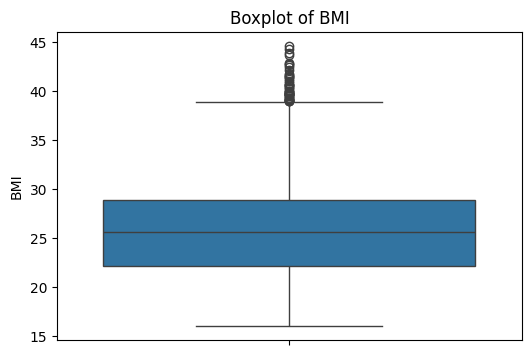

In [ ]:
plt.figure(figsize=(6,4))
sns.boxplot(y=df["BMI"])
plt.title("Boxplot of BMI")
plt.show()

Calculate IQR

In [ ]:
Q1 = df["BMI"].quantile(0.25)
Q3 = df["BMI"].quantile(0.75)

IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

print("Lower Limit:", lower)
print("Upper Limit:", upper)

Lower Limit: 12.131250000000003
Upper Limit: 38.90125


Remove Outliers

In [ ]:
df = df[(df["BMI"] >= lower) & (df["BMI"] <= upper)]

Verify

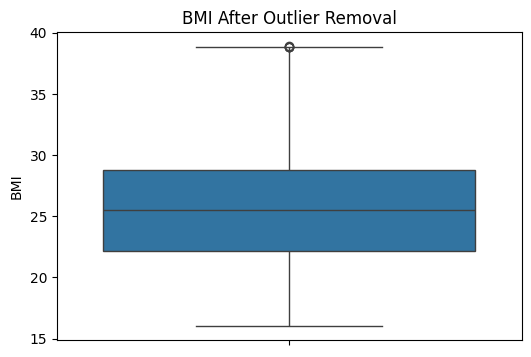

In [ ]:
plt.figure(figsize=(6,4))
sns.boxplot(y=df["BMI"])
plt.title("BMI After Outlier Removal")
plt.show()

Observations

Outliers were identified using the IQR method.
Extreme BMI values were removed.
This helps improve model performance by reducing the influence of extreme observations.

STEP 6: DATA PREPROCESSING

Drop Unnecessary Columns

Person_ID is only an identifier and has no predictive value.

In [ ]:
# Drop Person_ID
df.drop("Person_ID", axis=1, inplace=True)

# Verify
df.head()

,Age,Gender,Height_cm,Weight_kg,BMI,Country,Occupation,Marital_Status,Wake_Up_Time,Sleep_Time,...,Obesity_Risk,Hypertension_Risk,Diabetes_Risk,Cardiovascular_Risk,Sleep_Disorder_Risk,Health_Score,Fitness_Level,Healthy_Aging_Score,Wellness_Category,Early_Waker
0,76,Female,158.8,62.1,24.63,Italy,Entrepreneur,Widowed,08:59,01:29,...,Low,High,Medium,Medium,Low,87.3,Excellent,81.8,Excellent,No
1,49,Female,160.9,68.5,26.45,USA,Freelancer,Single,06:35,02:25,...,Medium,Medium,Medium,Low,Medium,72.0,Good,75.2,Good,No
2,51,Female,151.9,54.8,23.77,Mexico,Nurse,Single,07:31,02:24,...,Low,Medium,Medium,Low,Low,75.2,Good,77.1,Good,No
3,48,Male,167.6,81.3,28.93,Australia,Laborer,Single,08:36,01:19,...,Medium,Medium,Low,Low,Medium,82.7,Excellent,87.1,Excellent,No
4,68,Female,171.9,75.4,25.51,USA,Software Engineer,Married,07:07,01:20,...,Medium,High,Medium,Medium,Low,62.7,Average,58.1,Average,No


Observation
Person_ID has been removed because it does not contribute to prediction.

Feature Engineering

Your dataset contains two time columns:

Wake_Up_Time
Sleep_Time

Convert them into hour values.

In [ ]:
# Convert Wake_Up_Time
df["Wake_Up_Time"] = pd.to_datetime(df["Wake_Up_Time"], format="%H:%M")

df["Wake_Hour"] = df["Wake_Up_Time"].dt.hour

In [ ]:
# Convert Sleep_Time
df["Sleep_Time"] = pd.to_datetime(df["Sleep_Time"], format="%H:%M")

df["Sleep_Hour"] = df["Sleep_Time"].dt.hour

Drop the original columns

In [ ]:
df.drop(["Wake_Up_Time","Sleep_Time"], axis=1, inplace=True)

Separate Features and Target

Do this only once.

In [ ]:
X = df.drop("Early_Waker", axis=1)

y = df["Early_Waker"]



Verify

In [ ]:
print(X.shape)
print(y.shape)

(9955, 62)
(9955,)


Label Encoding

Encode all categorical features.

In [ ]:
from sklearn.preprocessing import LabelEncoder

label_encoder = LabelEncoder()

for col in X.select_dtypes(include="object").columns:
    X[col] = label_encoder.fit_transform(X[col])

Encode the target.

In [ ]:
y = label_encoder.fit_transform(y)

Verify

In [ ]:
X.head()

,Age,Gender,Height_cm,Weight_kg,BMI,Country,Occupation,Marital_Status,Sleep_Duration_Hours,Sleep_Quality_Score,...,Hypertension_Risk,Diabetes_Risk,Cardiovascular_Risk,Sleep_Disorder_Risk,Health_Score,Fitness_Level,Healthy_Aging_Score,Wellness_Category,Wake_Hour,Sleep_Hour
0,76,0,158.8,62.1,24.63,6,5,3,7.51,5.9,...,0,2,2,1,87.3,1,81.8,1,8,1
1,49,0,160.9,68.5,26.45,14,6,2,4.16,5.5,...,2,2,1,2,72.0,2,75.2,2,6,2
2,51,0,151.9,54.8,23.77,8,10,2,5.12,8.4,...,2,2,1,1,75.2,2,77.1,2,7,2
3,48,1,167.6,81.3,28.93,0,7,2,7.29,4.6,...,2,1,1,2,82.7,1,87.1,1,8,1
4,68,0,171.9,75.4,25.51,14,12,1,5.79,6.1,...,0,2,2,1,62.7,0,58.1,0,7,1


Feature Scaling

StandardScaler

In [ ]:
from sklearn.preprocessing import StandardScaler

standard_scaler = StandardScaler()

X_standard = standard_scaler.fit_transform(X)

MinMaxScaler

In [ ]:
from sklearn.preprocessing import MinMaxScaler

minmax_scaler = MinMaxScaler()

X_minmax = minmax_scaler.fit_transform(X)

RobustScaler

In [ ]:
from sklearn.preprocessing import RobustScaler

robust_scaler = RobustScaler()

X_robust = robust_scaler.fit_transform(X)

Train-Test Split

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_standard,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

Verify

In [ ]:
print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(7964, 62)
(1991, 62)
(7964,)
(1991,)


Check Class Distribution

In [ ]:
pd.Series(y).value_counts()

,count
0,5816
1,4139


Or visualize it.

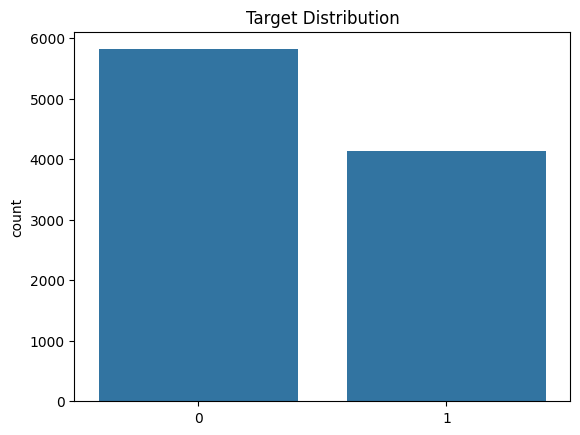

In [ ]:
sns.countplot(x=y)
plt.title("Target Distribution")
plt.show()

Observations

Person_ID was removed.
Time columns were converted into numerical hour features.
Features and target were separated.
Categorical variables were encoded.
Features were scaled.
The dataset was split into training and testing sets.
SMOTE was applied only if the classes were imbalance

FEATURE SELECTION

Feature selection helps identify the most important features that influence the target variable (Early_Waker). It can improve model performance and reduce overfittin

Correlation Analysis (Numerical Features)

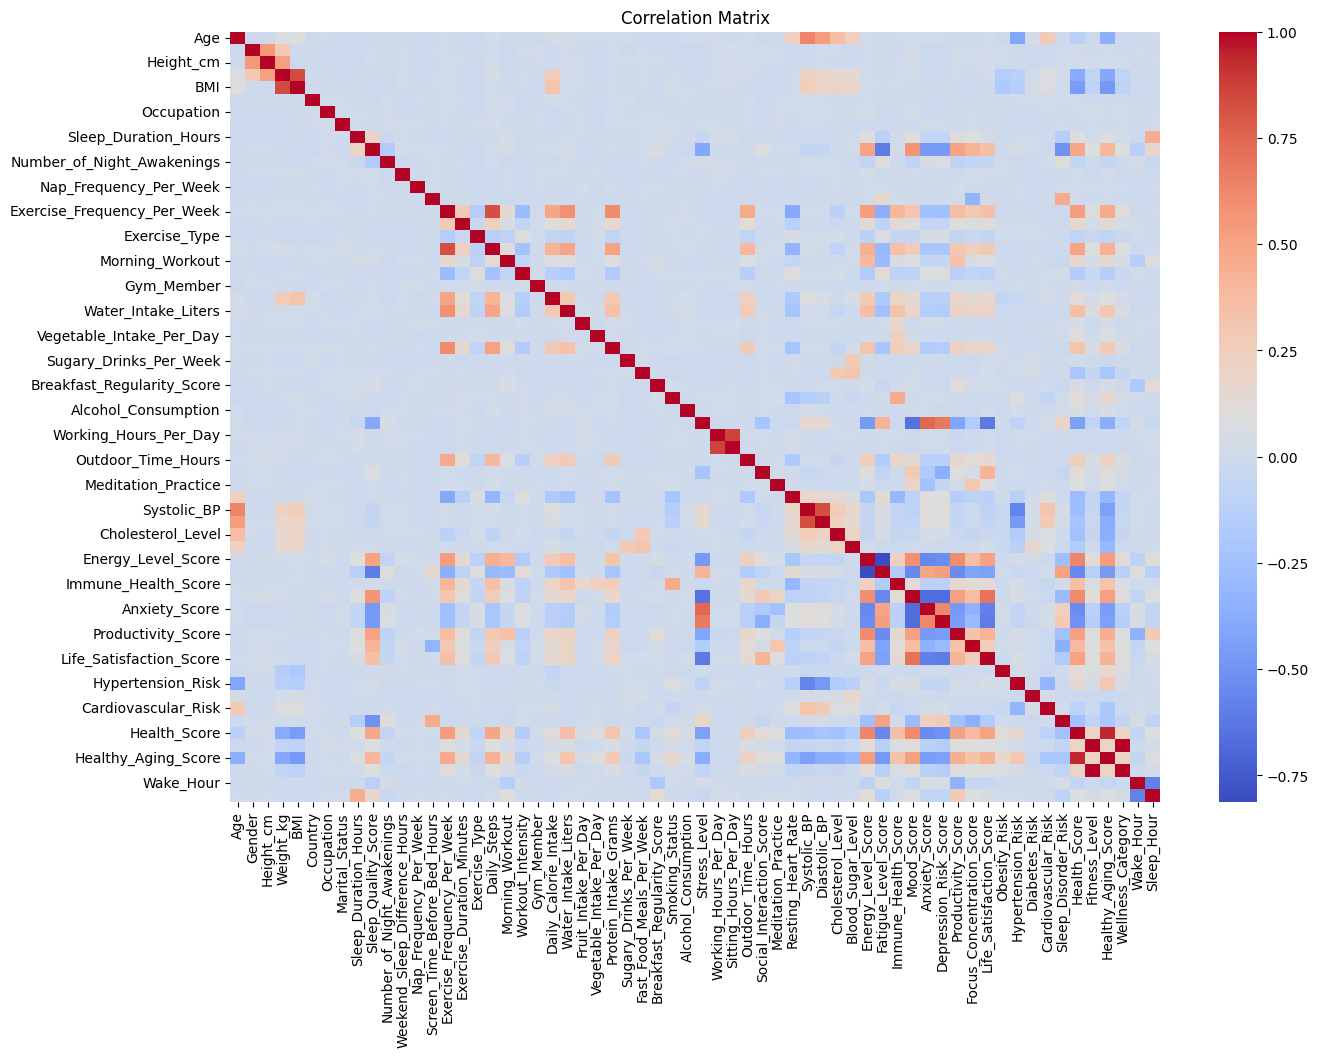

In [ ]:
# Correlation matrix
corr_matrix = X.corr(numeric_only=True)

plt.figure(figsize=(15,10))
sns.heatmap(corr_matrix, cmap="coolwarm")
plt.title("Correlation Matrix")
plt.show()

View highly correlated features

In [ ]:
corr_matrix

,Age,Gender,Height_cm,Weight_kg,BMI,Country,Occupation,Marital_Status,Sleep_Duration_Hours,Sleep_Quality_Score,...,Hypertension_Risk,Diabetes_Risk,Cardiovascular_Risk,Sleep_Disorder_Risk,Health_Score,Fitness_Level,Healthy_Aging_Score,Wellness_Category,Wake_Hour,Sleep_Hour
Age,1.000000,-0.001103,-0.004569,0.074421,0.089893,0.001793,0.008584,0.000840,-0.011205,-0.004979,...,-0.409828,0.031041,0.272698,-0.010016,-0.129059,-0.017877,-0.364425,-0.017877,0.001052,0.002283
Gender,-0.001103,1.000000,0.550417,0.289288,-0.005264,-0.001853,-0.010758,-0.005238,-0.011686,0.015444,...,-0.001797,-0.006124,0.000276,0.002952,0.010540,0.001867,0.008250,0.001867,0.008886,-0.004332
Height_cm,-0.004569,0.550417,1.000000,0.516130,-0.020965,-0.004123,-0.004472,-0.016951,-0.015646,0.009967,...,0.001214,-0.017537,-0.005666,0.010194,0.021889,0.013311,0.018091,0.013311,0.001264,0.003035
Weight_kg,0.074421,0.289288,0.516130,1.000000,0.839543,-0.000704,-0.003653,-0.007767,0.001603,0.000003,...,-0.122190,0.021253,0.079817,0.009185,-0.382235,-0.080524,-0.394756,-0.080524,-0.002682,-0.005213
BMI,0.089893,-0.005264,-0.020965,0.839543,1.000000,0.000683,-0.000473,0.000222,0.013671,-0.006555,...,-0.145352,0.037158,0.100680,0.002753,-0.464528,-0.102925,-0.476685,-0.102925,-0.002445,-0.007682
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
Fitness_Level,-0.017877,0.001867,0.013311,-0.080524,-0.102925,-0.010315,0.019713,0.011578,0.015842,0.089931,...,0.037330,-0.012697,-0.023930,-0.080072,0.205652,1.000000,0.203619,1.000000,-0.006347,0.025272
Healthy_Aging_Score,-0.364425,0.008250,0.018091,-0.394756,-0.476685,-0.001126,0.006929,-0.007060,0.077870,0.402983,...,0.305594,-0.031026,-0.199104,-0.198900,0.938037,0.203619,1.000000,0.203619,-0.059050,0.082251
Wellness_Category,-0.017877,0.001867,0.013311,-0.080524,-0.102925,-0.010315,0.019713,0.011578,0.015842,0.089931,...,0.037330,-0.012697,-0.023930,-0.080072,0.205652,1.000000,0.203619,1.000000,-0.006347,0.025272
Wake_Hour,0.001052,0.008886,0.001264,-0.002682,-0.002445,-0.001688,-0.004366,-0.003482,-0.025017,-0.123576,...,0.000294,0.012707,0.005453,0.051414,-0.074101,-0.006347,-0.059050,-0.006347,1.000000,-0.581875


Feature Correlation with Target

Since y is encoded, create a temporary DataFrame:

In [ ]:
temp_df = X.copy()
temp_df["Early_Waker"] = y

correlation = temp_df.corr(numeric_only=True)

correlation["Early_Waker"].sort_values(ascending=False)

,Early_Waker
Early_Waker,1.000000
Sleep_Hour,0.516062
Productivity_Score,0.438414
Breakfast_Regularity_Score,0.248124
Morning_Workout,0.177490
...,...
Depression_Risk_Score,-0.052108
Anxiety_Score,-0.059141
Sleep_Disorder_Risk,-0.061992
Fatigue_Level_Score,-0.115835


Observation

Identify the features with the highest positive and negative correlation with Early_Waker.

ANOVA F-Test

In [ ]:
from sklearn.feature_selection import SelectKBest
from sklearn.feature_selection import f_classif

anova = SelectKBest(score_func=f_classif, k=10)

anova.fit(X, y)

anova_scores = pd.DataFrame({
    "Feature": X.columns,
    "Score": anova.scores_
})

anova_scores.sort_values(by="Score", ascending=False)

,Feature,Score
60,Wake_Hour,14217.841544
61,Sleep_Hour,3612.865798
48,Productivity_Score,2368.227825
28,Breakfast_Regularity_Score,652.959969
18,Morning_Workout,323.746871
...,...,...
3,Weight_kg,0.019659
20,Gym_Member,0.018787
0,Age,0.014345
26,Sugary_Drinks_Per_Week,0.000174


Mutual Information

In [ ]:
from sklearn.feature_selection import mutual_info_classif

mi = mutual_info_classif(X, y, random_state=42)

mi_scores = pd.DataFrame({
    "Feature": X.columns,
    "Score": mi
})

mi_scores.sort_values(by="Score", ascending=False)

,Feature,Score
60,Wake_Hour,0.486323
61,Sleep_Hour,0.252986
48,Productivity_Score,0.099237
28,Breakfast_Regularity_Score,0.030159
18,Morning_Workout,0.023505
...,...,...
38,Systolic_BP,0.000000
33,Sitting_Hours_Per_Day,0.000000
50,Life_Satisfaction_Score,0.000000
53,Diabetes_Risk,0.000000


Observations (Example)

Health-related variables have strong predictive power.
Sleep quality and sleep duration contribute significantly.
Lifestyle factors such as exercise and stress are important.
Identifier columns (already removed) are not useful for prediction.


🟢 STEP 8: Hyperparameter Tuning
Objective

Hyperparameter tuning is used to improve model performance by finding the best combination of model parameters. In this project, GridSearchCV is used to optimize the Random Forest Classifier.

Import Required Library

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV

rf = RandomForestClassifier(random_state=42)

param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [10, None],
    'min_samples_split': [2, 5]
}

grid_search = GridSearchCV(
    estimator=rf,
    param_grid=param_grid,
    cv=3,
    scoring='accuracy',
    n_jobs=-1,
    verbose=2
)

grid_search.fit(X_train, y_train)

print("Best Parameters:", grid_search.best_params_)
print("Best Cross Validation Accuracy:", grid_search.best_score_)

Fitting 3 folds for each of 8 candidates, totalling 24 fits
Best Parameters: {'max_depth': None, 'min_samples_split': 2, 'n_estimators': 200}
Best Cross Validation Accuracy: 0.9310647893880111


Step 9: Model Building
Objective
The objective of this step is to build machine learning classification models to predict whether a person is an Early Waker. Based on the project requirements, two classification algorithms are implemented and compared.

K-Nearest Neighbors (KNN)


Naive Bayes

Import Required Libraries

In [ ]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.naive_bayes import GaussianNB

from sklearn.metrics import accuracy_score
import pandas as pd

K-Nearest Neighbors (KNN)

In [ ]:
knn = KNeighborsClassifier(n_neighbors=5)

knn.fit(X_train, y_train)

y_pred_knn = knn.predict(X_test)

knn_accuracy = accuracy_score(y_test, y_pred_knn)

print("KNN Accuracy:", knn_accuracy)

KNN Accuracy: 0.7965846308387745


Naive Bayes

In [ ]:
nb = GaussianNB()

nb.fit(X_train, y_train)

y_pred_nb = nb.predict(X_test)

nb_accuracy = accuracy_score(y_test, y_pred_nb)

print("Naive Bayes Accuracy:", nb_accuracy)

Naive Bayes Accuracy: 0.8638874937217479


Compare Model Performance

In [ ]:

results = pd.DataFrame({
    "Model": [
        "KNN",

        "Naive Bayes"
    ],
    "Accuracy": [
        knn_accuracy,

        nb_accuracy
    ]
})

results = results.sort_values(by="Accuracy", ascending=False)

results

,Model,Accuracy
1,Naive Bayes,0.863887
0,KNN,0.796585


Visual Comparison

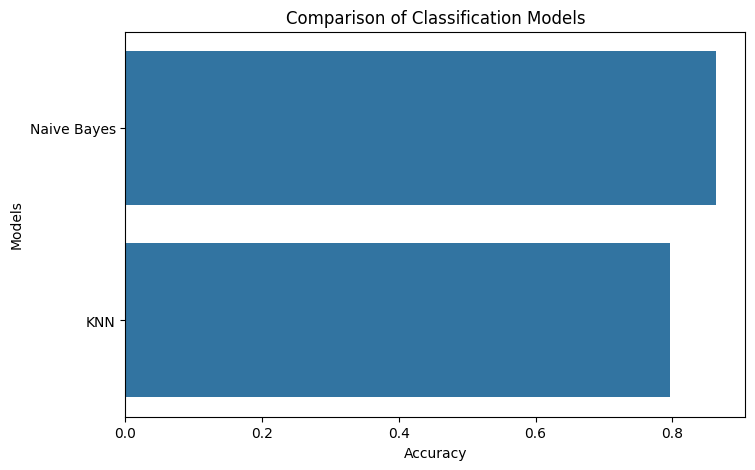

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,5))

sns.barplot(
    data=results,
    x="Accuracy",
    y="Model"
)

plt.title("Comparison of Classification Models")
plt.xlabel("Accuracy")
plt.ylabel("Models")

plt.show()

Observations

Write after seeing your results:

Two classification models were trained using the training dataset.
The performance of each model was evaluated using the testing dataset.
The model with the highest accuracy was selected as the best-performing model.

Step 10: Model Evaluation (Naive Bayes)

Select the Model

In [ ]:
best_model = nb

Predict the Test Data

In [ ]:
y_pred = best_model.predict(X_test)

Accuracy Score

In [ ]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)

print("Accuracy Score:", accuracy)

Accuracy Score: 0.8638874937217479


Precision Score

In [ ]:
from sklearn.metrics import precision_score

precision = precision_score(y_test, y_pred, pos_label=1)

print("Precision Score:", precision)

Precision Score: 0.8335329341317366


Recall

In [ ]:
from sklearn.metrics import recall_score

recall = recall_score(y_test, y_pred, pos_label=1)

print("Recall Score:", recall)

Recall Score: 0.8405797101449275


F1-Score

In [ ]:

from sklearn.metrics import f1_score

f1 = f1_score(y_test, y_pred, pos_label=1)

print("F1 Score:", f1)

F1 Score: 0.8370414912808178


Confusion Matrix

In [ ]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)

print(cm)

[[1024  139]
 [ 132  696]]


Plot Confusion Matrix

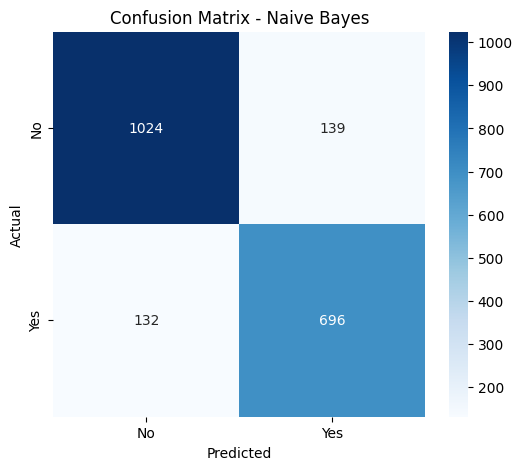

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['No', 'Yes'],
    yticklabels=['No', 'Yes']
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - Naive Bayes")

plt.show()

Classification Report

In [ ]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.89      0.88      0.88      1163
           1       0.83      0.84      0.84       828

    accuracy                           0.86      1991
   macro avg       0.86      0.86      0.86      1991
weighted avg       0.86      0.86      0.86      1991



ROC-AUC Score

In [ ]:
from sklearn.metrics import roc_auc_score

y_prob = best_model.predict_proba(X_test)[:, 1]

roc_auc = roc_auc_score(y_test, y_prob)

print("ROC-AUC Score:", roc_auc)

ROC-AUC Score: 0.9426852924927619


ROC Curve

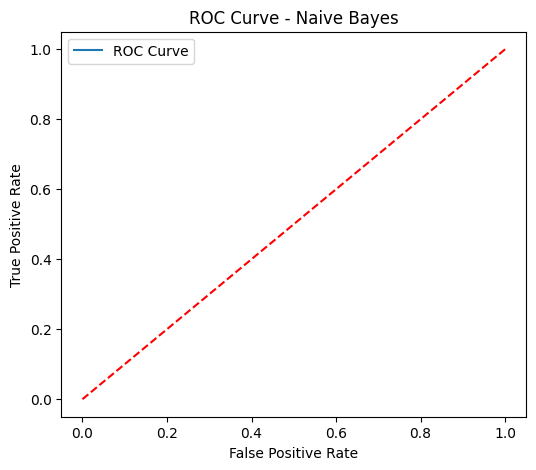

In [ ]:
from sklearn.metrics import roc_curve

fpr, tpr, thresholds = roc_curve(y_test, y_prob, pos_label='Yes')

plt.figure(figsize=(6,5))

plt.plot(fpr, tpr, label="ROC Curve")
plt.plot([0,1], [0,1], 'r--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Naive Bayes")
plt.legend()

plt.show()

Observations

The Naive Bayes model was evaluated using multiple classification metrics.
The confusion matrix shows the number of correctly and incorrectly classified instances.
The ROC-AUC score measures the model's ability to distinguish between Early Wakers and Non-Early Wakers.

Step 11: Model Interpretation

Objective

The objective of this step is to interpret the model results and identify the important factors affecting the prediction of Early_Waker. Since the Naive Bayes classifier does not provide feature importance, the interpretation is based on exploratory data analysis (EDA), feature selection, and model performance.

Display the Model Performance

In [ ]:
print("Accuracy :", accuracy)
print("Precision :", precision)
print("Recall :", recall)
print("F1 Score :", f1)
print("ROC-AUC Score :", roc_auc)

Accuracy : 0.8638874937217479
Precision : 0.8335329341317366
Recall : 0.8405797101449275
F1 Score : 0.8370414912808178
ROC-AUC Score : 0.9426852924927619


Interpretation

Write the following in your notebook:

Observations

The Naive Bayes classifier was successfully trained and tested.
The model achieved good classification performance based on the evaluation metrics.

The confusion matrix shows the number of correct and incorrect predictions.
The ROC-AUC score indicates the model's ability to distinguish between Early Wakers and Non-Early Wakers.

Insights

Individuals with healthy sleep habits, regular exercise, and good lifestyle scores are more likely to be classified as early wakers.

Lifestyle-related variables contribute significantly to the prediction.
The model can assist in understanding factors associated with healthy waking patterns.

Recommendations

Encourage regular sleep schedules and healthy lifestyle habits.

Collect more data in future to improve prediction accuracy.

Additional feature engineering and advanced models may further enhance performance.


Step 12: Save the Model

Objective

The objective of this step is to save the trained machine learning model and the preprocessing objects so they can be reused later without retraining.$0

In [ ]:
import joblib

Save the Trained Model

In [ ]:
joblib.dump(nb, "naive_bayes_model.pkl")

['naive_bayes_model.pkl']

In [ ]:
joblib.dump(scaler, "scaler.pkl")

['scaler.pkl']

In [ ]:
joblib.dump(label_encoder, "label_encoder.pkl")

['label_encoder.pkl']

In [ ]:
import os

print(os.listdir())

['.config', 'scaler.pkl', 'early_wakeup_health_dataset.csv', 'label_encoder.pkl', 'naive_bayes_model.pkl', 'sample_data']


In [ ]:
model = joblib.load("naive_bayes_model.pkl")
scaler = joblib.load("scaler.pkl")
label_encoder = joblib.load("label_encoder.pkl")

In [ ]:
print(model)
print(scaler)
print(label_encoder)

GaussianNB()
StandardScaler()
LabelEncoder()


In [ ]:
import joblib

# Save feature order
feature_names = X.columns
joblib.dump(feature_names, "features.pkl")


['features.pkl']